In [1]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google'

In [2]:
from google.colab import files
uploaded = files.upload()

Saving pandas (1).ipynb to pandas (1).ipynb


In [3]:
from google.colab import files
uploaded = files.upload()

Saving kleibers_law_data (1).csv to kleibers_law_data (1).csv


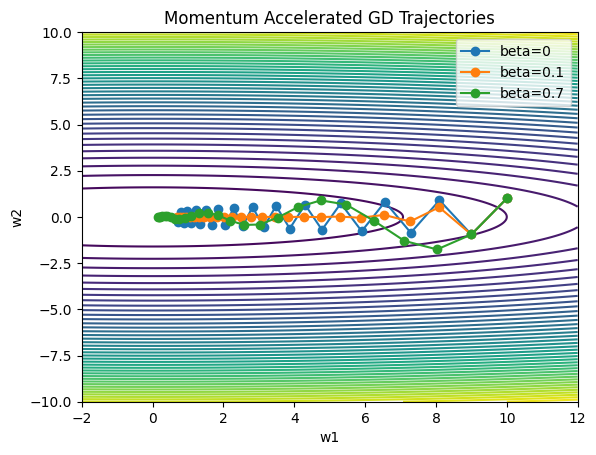

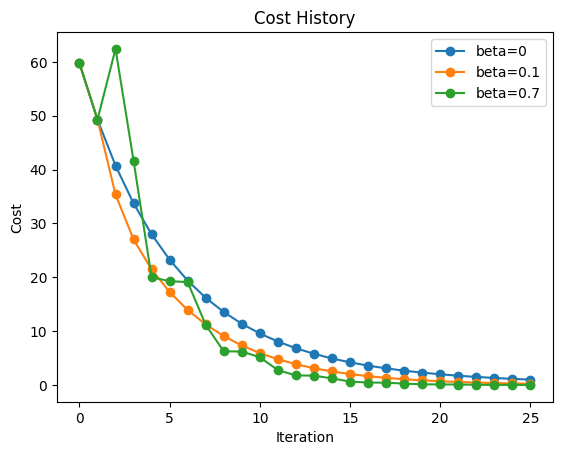

In [9]:
import autograd.numpy as np
from autograd import value_and_grad
import matplotlib.pyplot as plt
C = np.array([[0.5,0],[0,9.75]])
g = lambda w: np.dot(w.T, np.dot(C, w))
vg = value_and_grad(g)
def momentum_gd(g, w0, alpha, max_its, beta):
    ws = [w0]
    costs = [g(w0)]
    d = vg(w0)[1]
    d = -d
    for i in range(max_its):
        grad_val = vg(ws[-1])[1]
        d = beta*d + (1-beta)*(-grad_val)
        w_new = ws[-1] + alpha*d
        ws.append(w_new)
        costs.append(g(w_new))
    return np.array(ws), np.array(costs)
betas = [0, 0.1, 0.7]
results = {}
for b in betas:
    ws, costs = momentum_gd(g, np.array([10.0,1.0]), 0.1, 25, b)
    results[b] = (ws, costs)
xgrid = np.linspace(-2,12,400)
ygrid = np.linspace(-10,10,400)
X, Y = np.meshgrid(xgrid, ygrid)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        w = np.array([X[i,j], Y[i,j]])
        Z[i,j] = g(w)
plt.figure()
plt.contour(X, Y, Z, levels=50)
for b in betas:
    ws, costs = results[b]
    plt.plot(ws[:,0], ws[:,1], marker='o', label='beta='+str(b))
plt.xlabel('w1')
plt.ylabel('w2')
plt.legend()
plt.title('Momentum Accelerated GD Trajectories')
plt.figure()
for b in betas:
    ws, costs = results[b]
    plt.plot(range(len(costs)), costs, marker='o', label='beta='+str(b))
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.title('Cost History')
plt.show()


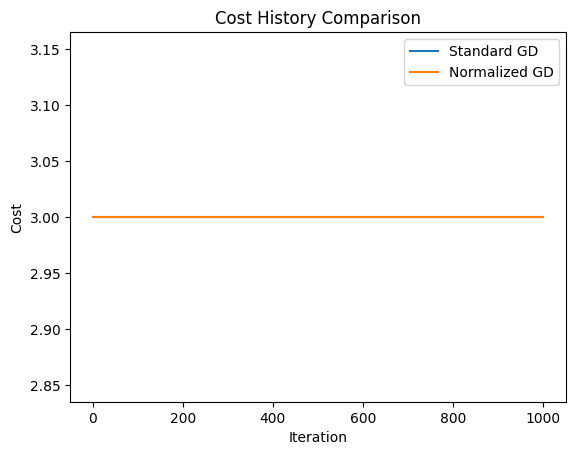

In [10]:
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
f = lambda w: np.tanh(4*(w[0]+w[1])) + np.maximum(1,0.4*w[1]) + 1
def standard_gd(f, w0, alpha, max_its):
    ws = [w0]
    costs = [f(w0)]
    grad_f = grad(f)
    w = w0
    for i in range(max_its):
        w = w - alpha * grad_f(w)
        ws.append(w)
        costs.append(f(w))
    return np.array(ws), np.array(costs)
def normalized_gd(f, w0, alpha, max_its, eps=1e-8):
    ws = [w0]
    costs = [f(w0)]
    grad_f = grad(f)
    w = w0
    for i in range(max_its):
        g_val = grad_f(w)
        w = w - alpha * g_val/(np.linalg.norm(g_val)+eps)
        ws.append(w)
        costs.append(f(w))
    return np.array(ws), np.array(costs)
w0 = np.array([2.0,2.0])
alpha = 0.1
max_its = 1000
ws_std, costs_std = standard_gd(f, w0, alpha, max_its)
ws_norm, costs_norm = normalized_gd(f, w0, alpha, max_its)
plt.figure()
plt.plot(costs_std, label='Standard GD')
plt.plot(costs_norm, label='Normalized GD')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.title('Cost History Comparison')
plt.show()


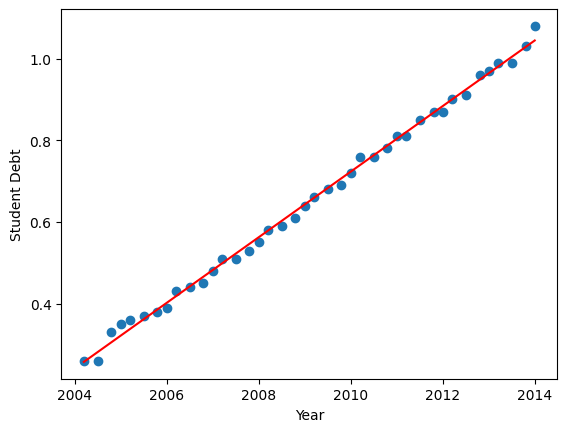

3.93601194914973


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = np.asarray(pd.read_csv('student_debt_data (1).csv', header=None))
x = data[:,0].reshape(-1,1)
o = np.ones((len(x),1))
X_new = np.concatenate((o,x), axis=1)
y = data[:,1]
A = X_new.T.dot(X_new)
b = X_new.T.dot(y)
w = np.linalg.pinv(A).dot(b)
plt.scatter(x,y)
x_line = np.linspace(np.min(x),np.max(x),100)
y_line = w[0] + w[1]*x_line
plt.plot(x_line,y_line,'r')
plt.xlabel('Year')
plt.ylabel('Student Debt')
plt.show()
print(w[0] + w[1]*2050)



<ipython-input-12-bed48eca2cff>:12: RuntimeWarning: overflow encountered in square
  cost = lambda w, x, ly: np.sum((w[0] + w[1]*np.log(x) - ly)**2)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-12-bed48eca2cff>:12: RuntimeWarning: invalid value encountered in multiply
  cost = lambda w, x, ly: np.sum((w[0] + w[1]*np.log(x) - ly)**2)
<ipython-input-12-bed48eca2cff>:12: RuntimeWarning: invalid value encountered in add
  cost = lambda w, x, ly: np.sum((w[0] + w[1]*np.log(x) - ly)**2)
<ipython-input-12-bed48eca2cff>:17: RuntimeWarning: invalid value encountered in multiply
  grad_w0 = 2*np.sum(w[0] + w[1]*np.log(x) - ly)
<ipython-input-12-bed48eca2cff>:17: RuntimeWarning: invalid value encountered in add
  grad_w0 = 2*np.sum(w[0] + w[1]*np.log(x) - ly)
<ipython-input-12-bed48eca2cff>:18: RuntimeWarning: invalid value encountered in multiply
  gr

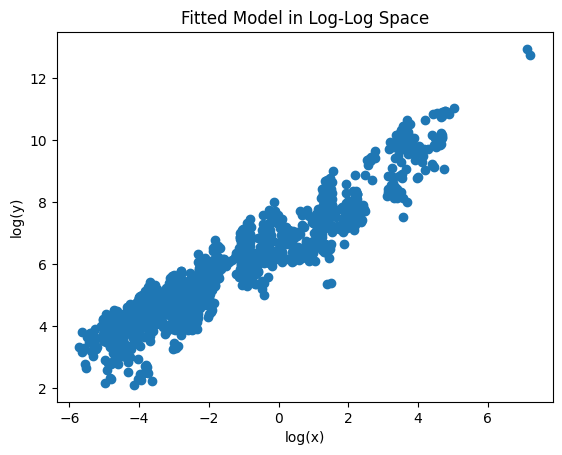

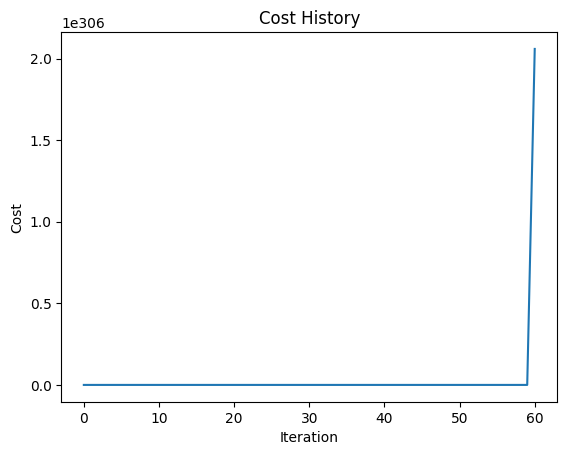

nan


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('kleibers_law_data (1).csv', header=None, sep=None, engine='python')
if data.shape[1] > 2:
    data = data.transpose()
x = data.iloc[:,0].values
y = data.iloc[:,1].values
lx = np.log(x)
ly = np.log(y)
model = lambda w, x: w[0] + w[1]*np.log(x)
cost = lambda w, x, ly: np.sum((w[0] + w[1]*np.log(x) - ly)**2)
w = np.random.randn(2)*0.1
alpha = 0.01
cost_history = []
for i in range(1000):
    grad_w0 = 2*np.sum(w[0] + w[1]*np.log(x) - ly)
    grad_w1 = 2*np.sum((w[0] + w[1]*np.log(x) - ly)*np.log(x))
    w[0] = w[0] - alpha*grad_w0
    w[1] = w[1] - alpha*grad_w1
    cost_history.append(cost(w,x,ly))
plt.figure()
plt.scatter(np.log(x),ly)
lx_line = np.linspace(np.min(np.log(x)),np.max(np.log(x)),100)
ly_line = w[0] + w[1]*lx_line
plt.plot(lx_line,ly_line,'r')
plt.xlabel('log(x)')
plt.ylabel('log(y)')
plt.title('Fitted Model in Log-Log Space')
plt.figure()
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost History')
plt.show()
pred_logy = w[0] + w[1]*np.log(10)
pred_y = np.exp(pred_logy)
calories = (pred_y*1000)/4.18
print(calories)


In [13]:
import pandas as pd
df1 = pd.read_csv('student_debt_data (1).csv', header=None)
df1.columns = ['Year','Debt']
df2 = pd.read_csv('kleibers_law_data (1).csv', header=None, sep=None, engine='python')
if df2.shape[1] > 2:
    df2 = df2.transpose()
df2.columns = ['Mass','Metabolic']
print(df1.head())
print(df1.describe())
print(df2.head())
print(df2.describe())
print(df2.sort_values('Metabolic', ascending=False).head())


     Year  Debt
0  2004.2  0.26
1  2004.5  0.26
2  2004.8  0.33
3  2005.0  0.35
4  2005.2  0.36
              Year      Debt
count    40.000000  40.00000
mean   2009.125000   0.65275
std       2.925025   0.23535
min    2004.200000   0.26000
25%    2006.725000   0.44750
50%    2009.100000   0.65000
75%    2011.575000   0.85500
max    2014.000000   1.08000
      Mass  Metabolic
0  1370.00   345000.0
1  1250.00   417000.0
2     7.40     3100.0
3     6.95     2898.0
4     8.90     3528.0
              Mass      Metabolic
count  1498.000000    1498.000000
mean      6.603513    2538.732001
std      50.535808   15363.323907
min       0.003300       8.210000
25%       0.018750      74.337500
50%       0.088075     181.900000
75%       0.922750     811.775000
max    1370.000000  417000.000000
       Mass  Metabolic
1    1250.0   417000.0
0    1370.0   345000.0
188   154.8    62192.0
184   119.8    57032.0
187   118.9    56193.0


This assignment comprises five exercises that showcase various optimization and data analysis techniques. In Exercise 1, a momentum-accelerated gradient descent is implemented to minimize a quadratic function, with weight trajectories and cost histories plotted for different momentum parameters. Exercise 2 compares standard and fully normalized gradient descent on a non-linear function, illustrating their convergence behaviors. Exercise 3 applies a single Newton step for linear regression on student debt data to determine the best-fit line and predict future values. In Exercise 4, gradient descent is used to optimize a log-transformed linear regression model on metabolic data based on Kleiber’s law, including a prediction of caloric needs. Finally, Exercise 5 leverages Pandas for data manipulation and exploratory analysis of the provided datasets. Each exercise is encapsulated in its own code cell, ensuring seamless execution in Google Colab.






